In [ ]:
# 既にインストールされていれば不要
!pip install quri-parts
!pip install "quri-parts[qulacs]"

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

n_qubits = 3 # 使用する量子ビット数
func_to_learn = lambda x: np.sin(x*np.pi) # 学習したい 1 変数関数

# [x_min, x_max]のうち, ランダムにnum_x_train個の点をとって教師データとする
x_min = -1.; x_max = 1.
num_x_train = 50

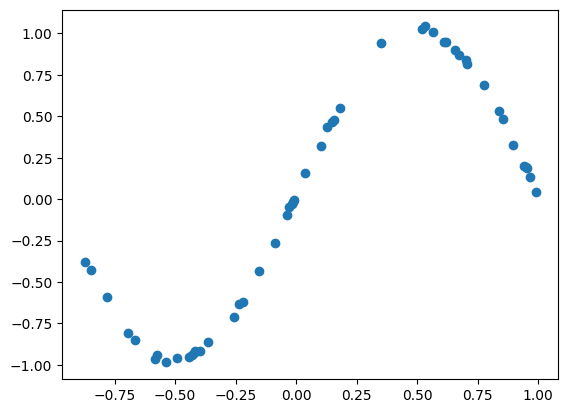

In [ ]:
  # シード値を固定した乱数生成器の作成
rng = np.random.default_rng(2025)

# ノイズありの教師データを作成
mag_noise = 0.05
x_train = x_min + (x_max - x_min) * rng.random(num_x_train)
y_train = func_to_learn(x_train)
y_train = y_train + mag_noise * rng.random(num_x_train)

plt.plot(x_train, y_train, "o")
plt.show()

補足：このセルの出力は書籍と若干異なります。

In [ ]:
from quri_parts.circuit import QuantumCircuit
from quri_parts.core.state import quantum_state, apply_circuit
from quri_parts.qulacs.simulator import evaluate_state_to_vector

# 入力データ x を量子状態にエンコードする回路
def U_in(x):
    U = QuantumCircuit(n_qubits)
    angle_y = np.arcsin(x)
    angle_z = np.arccos(x**2)
    for i in range(n_qubits):
        U.add_RY_gate(i, angle_y)
        U.add_RZ_gate(i, angle_z)
    return U

# エンコードされた量子状態U_in(x)|000>を確認
x = 0.1
print(evaluate_state_to_vector(apply_circuit(U_in(x), quantum_state(n_qubits))).vector)

[-6.93804351e-01-7.14937415e-01j  3.54871219e-02-3.51340074e-02j
  3.54871219e-02-3.51340074e-02j  1.77881430e-03+1.76111422e-03j
  3.54871219e-02-3.51340074e-02j  1.77881430e-03+1.76111422e-03j
  1.77881430e-03+1.76111422e-03j -8.73809020e-05+9.00424970e-05j]


In [ ]:
from scipy.linalg import expm
from quri_parts.core.operator import Operator, pauli_label, get_sparse_matrix

def get_hamiltonian():
    ham = Operator()
    for i in range(n_qubits):
        a_j = -1. + 2.*rng.random() # -1~1 の乱数
        ham.add_term(pauli_label(f"X{i}"), a_j)
        for j in range(i-1):
            J_jk = -1. + 2.*rng.random() # -1~1 の乱数
            ham.add_term(pauli_label(f"Z{i} Z{j}"), J_jk)
    return get_sparse_matrix(ham)

time_step = 0.77 # 時間発展の時間幅
ham = get_hamiltonian()
time_evol_op = QuantumCircuit(n_qubits) # 時間発展を行う回路
time_evol_op.add_UnitaryMatrix_gate(range(n_qubits), expm(-1j * ham.toarray() * time_step))

In [ ]:
from quri_parts.circuit import UnboundParametricQuantumCircuit
c_depth = 3 # 変分量子回路の深さ
def get_U_out() -> UnboundParametricQuantumCircuit:
    U_out = UnboundParametricQuantumCircuit(n_qubits)
    for _ in range(c_depth):
        U_out.extend(time_evol_op.gates)
        for i in range(n_qubits):
            U_out.add_ParametricRX_gate(i)
            U_out.add_ParametricRZ_gate(i)
            U_out.add_ParametricRX_gate(i)
    return U_out

U_out = get_U_out()

In [ ]:
from quri_parts.core.operator import pauli_label, Operator
from quri_parts.qulacs.estimator import create_qulacs_vector_estimator

# 出力の観測量を定義, 2 倍していることに注意
obs = Operator({pauli_label("Z0"): 2})
# 入力 x に対して量子回路を適用し, 2*Z0 の期待値を出力する関数
def qcl_pred(x: int, U_out: QuantumCircuit) -> float:
    # 状態準備
    state = quantum_state(n_qubits)
    state = apply_circuit(U_in(x), state)
    state = apply_circuit(U_out, state)
    # 期待値を計算して出力
    estimator = create_qulacs_vector_estimator()
    return estimator(obs, state).value.real

In [ ]:
# 最適化のコスト関数, theta の長さは 3 * n_qubits * c_depth
def cost_func(theta: list[float]) -> float:
    bound_U_out = U_out.bind_parameters(theta) # theta を代入
    y_pred = np.array([qcl_pred(x, bound_U_out) for x in x_train])
    L = ((y_pred - y_train)**2).mean() # 平均二乗誤差
    return L

# 初期値の theta をランダムに決定し, 予測結果を記録 (後でプロット)
random_init_param = 2 * np.pi * rng.random(U_out.parameter_count)
xlist = np.arange(x_min, x_max, 0.02)
y_init = [qcl_pred(x, U_out.bind_parameters(random_init_param)) for x in xlist]

In [ ]:
%%time
from scipy.optimize import minimize
# 学習 (環境によっては時間がかかる)
result = minimize(cost_func, random_init_param, method='SLSQP')
print("final cost:", result.fun)

final cost: 0.004494925086990202
CPU times: user 40.9 s, sys: 301 ms, total: 41.2 s
Wall time: 25.5 s


補足：`Initial Model Prediction`の値は、書籍版と異なります。

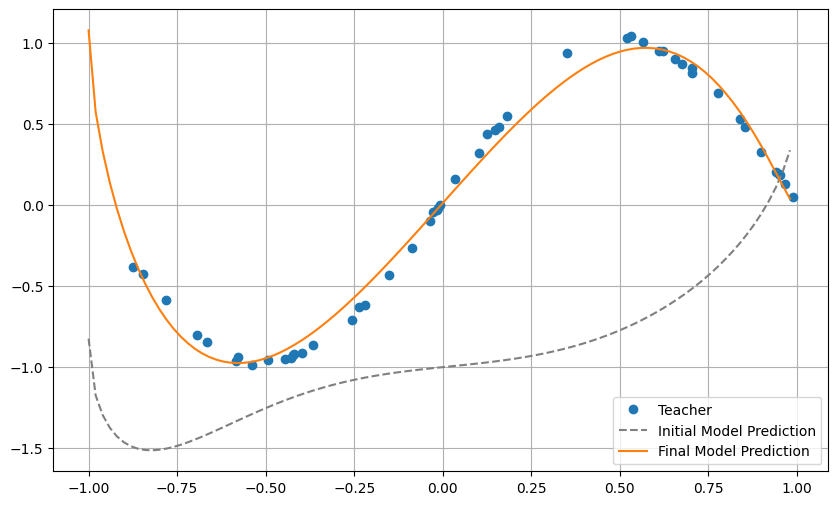

In [ ]:
plt.figure(figsize=(10, 6))
xlist = np.arange(x_min, x_max, 0.02) # プロット用のデータ点
plt.plot(x_train, y_train, "o", label='Teacher') # 教師データ
plt.plot(xlist, y_init, '--', label='Initial Model Prediction', c='gray')
y_pred = np.array([qcl_pred(x, U_out.bind_parameters(result.x)) for x in xlist])
plt.plot(xlist, y_pred, label='Final Model Prediction')
plt.legend()
plt.grid()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from quri_parts.circuit import QuantumCircuit
from quri_parts.circuit import UnboundParametricQuantumCircuit
from quri_parts.core.state import quantum_state, apply_circuit
from quri_parts.core.operator import Operator, pauli_label
from quri_parts.qulacs.estimator import create_qulacs_vector_estimator

def create_PQC(n_qubits, c_depth):
    circuit = UnboundParametricQuantumCircuit(n_qubits)
    for _ in range(c_depth):
        for i in range(n_qubits):
            circuit.add_ParametricRX_gate(i)
            circuit.add_ParametricRZ_gate(i)
            circuit.add_ParametricRX_gate(i)
            for j in range(i+1, n_qubits):
                circuit.add_CNOT_gate(i,j)
    return circuit

# シード値を固定した乱数生成器の作成
rng = np.random.default_rng(2025)
# 観測量を定義
obs = Operator({pauli_label("Z0"): 1})
# 期待値を qulacs を用いて厳密に評価する
estimator = create_qulacs_vector_estimator()
# ランダムな回路パラメータを何個とって平均と分散を計算するか
n_trials = 100

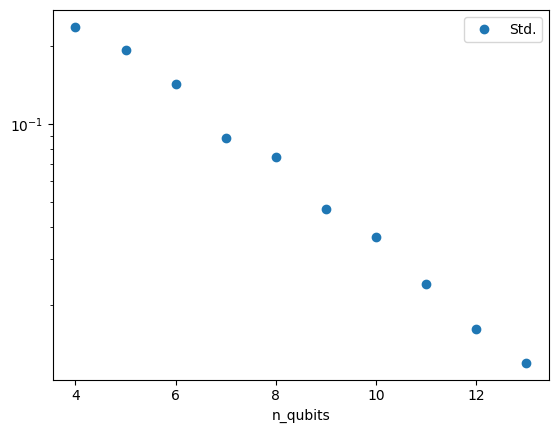

In [ ]:
n_qubits_list = np.arange(4,14)
ave_list = []; std_list = [] # 期待値の平均と標準偏差を記録
for n_qubits in n_qubits_list:
    c_depth = n_qubits # 変分量子回路の深さ
    circuit = create_PQC(n_qubits, c_depth) # 状態の作成
    exps = [] # 期待値を記録
    for _ in range(n_trials):
        # ランダムな theta をとって状態を生成し, 期待値を計算
        theta = 2 * np.pi * rng.random(circuit.parameter_count)
        state = quantum_state(n_qubits)
        state = apply_circuit(circuit.bind_parameters(theta), state)
        exp = estimator(obs, state).value.real
        exps.append(exp)
    ave_list.append(np.abs(np.mean(exps)))
    std_list.append(np.std(exps))

plt.semilogy(n_qubits_list, std_list, "o", label='Std.')
plt.xlabel("n_qubits")
plt.legend()
plt.show()